# 1) Imports and Setup

In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scipy.cluster.hierarchy as sch
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from adjustText import adjust_text

# Get the absolute path to the project root
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
models_path = os.path.join(project_root, 'models')
sys.path.append(models_path)

from DKT.dkt_model import DKT

# 2) Model and Data Imports


In [4]:
# Load the JSON file
best_config = {'learning_rate': 0.01,
               'model_params':
               {
            "num_skills": 15,
            "num_other": 5,
            "embed_dim": 7,
            "hid_size": 150,
            "num_hid_layers": 1,
            "drop_prob": 0.5
            }
               }
skills_file_path = os.path.join(os.getcwd(), '..', '..', 'data', 'preprocessed', 'df_skill_names.csv')
df_skill_names = pd.read_csv(skills_file_path)

skills_to_keep = [
    'Box and Whisker', 'Circle Graph', 'Histogram as Table or Graph', 'Number Line', 'Scatter Plot', 
        'Stem and Leaf Plot', 'Table', 'Venn Diagram', 'Mean', 'Median', 'Mode', 'Range',
    'Probability of Two Distinct Events', 'Probability of a Single Event', 'D.4.8-understanding-concept-of-probabilities'
]
df_skill_names = df_skill_names[df_skill_names['skill_name'].isin(skills_to_keep)]

num_skills = best_config['model_params']['num_skills']
embedding_dim = best_config['model_params']['embed_dim']


model = DKT(**best_config['model_params'])
model.load_state_dict(torch.load('dkt_full_model_skills_15.pth', map_location=torch.device('cpu')))
# Set the model to evaluation model
model.eval()


C:\Users\Botond\AppData\Local\Temp\ipykernel_9752\1427500187.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('dkt_full_model_skills_15.

DKT(
  (embedding): CustomEmbedding(
    (linear): Linear(in_features=15, out_features=7, bias=False)
  )
  (rnn): LSTM(12, 150, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (out): Linear(in_features=150, out_features=15, bias=True)
  (sigmoid): Sigmoid()
)

In [7]:
# Step 1: Create a mapping for the skill_name to categories
skill_groups = {

    "Data Graphs": [
        'Box and Whisker', 'Circle Graph', 'Histogram as Table or Graph', 'Number Line', 'Scatter Plot', 
        'Stem and Leaf Plot', 'Table', 'Venn Diagram'
    ],

    "Statistics": [
        'Mean', 'Median', 'Mode', 'Range'
    ],

    "Probability": [
        'Probability of Two Distinct Events', 'Probability of a Single Event', 'D.4.8-understanding-concept-of-probabilities'
    ]
}

# Step 2: Create a mapping for skill_name to group
skill_name_to_group = {skill: group for group, skills in skill_groups.items() for skill in skills}

# Step 3: Add the category to the dataframe
df_skill_names['category'] = df_skill_names['skill_name'].map(skill_name_to_group)


In [9]:
embedding_list = []

# Loop over all skill IDs to generate embeddings
for skill_id in range(num_skills):
    embedding = model.get_embedding(skill_id)
    embedding_list.append(embedding)

df_embeddings = pd.DataFrame(embedding_list, columns=[f"embedding_{i+1}" for i in range(embedding_dim)], index=[f"skill_{i+1}" for i in range(num_skills)])
df_embeddings['skill_name'] = df_skill_names['skill_name'].values
df_embeddings['category'] = df_skill_names['category'].values

df_embeddings = df_embeddings[df_embeddings['skill_name'].notna()]
print(df_embeddings)

          embedding_1  embedding_2  embedding_3  embedding_4  embedding_5  \
skill_1     -0.823182    -0.556710    -0.362633     0.533309     0.800018   
skill_2     -0.050121    -0.169019    -0.327118    -0.130284    -0.121969   
skill_3     -0.439956    -0.169849    -0.001752     0.811101    -0.157652   
skill_4      0.062979     0.461711     0.059955    -0.019049     0.405621   
skill_5      1.020113    -0.132499    -0.541777    -0.341975    -0.503913   
skill_6     -0.701500     0.597851     0.480886     0.575428    -0.594449   
skill_7      0.175709     0.321196     0.312830    -0.062843    -0.289516   
skill_8      0.290270    -0.212684     0.033280     0.211732    -0.035904   
skill_9      0.897852    -0.071407    -0.054670    -0.492953     0.372754   
skill_10     0.003395     0.402620    -0.028894    -0.089599     0.331874   
skill_11     0.041008     0.468250     1.142448     0.702713    -0.558568   
skill_12     0.883004     0.658751     0.189174    -0.921047    -0.887403   

# 3) Visualizations

## 3.1) 3D Visualization


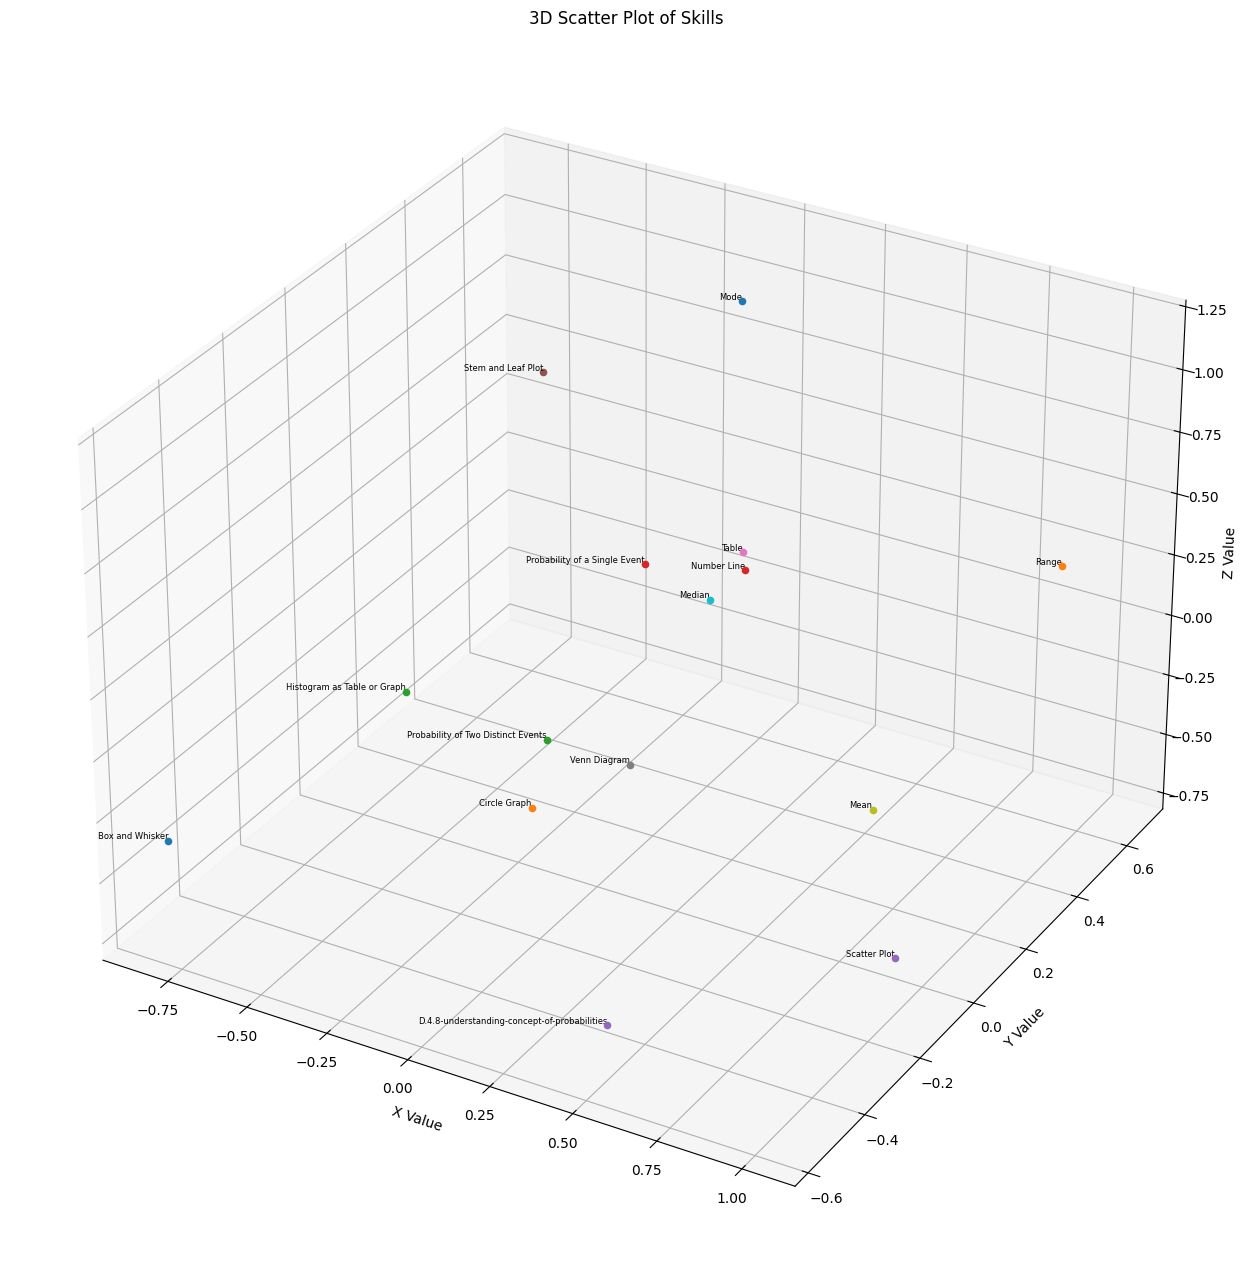

In [10]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
for i, row in df_embeddings.iterrows():
    ax.scatter(row['embedding_1'], row['embedding_2'], row['embedding_3'])  # 3D coordinates
    ax.text(row['embedding_1'], row['embedding_2'], row['embedding_3'], row['skill_name'], fontsize=6, ha='right', va='bottom')

ax.set_xlabel('X Value')
ax.set_ylabel('Y Value')
ax.set_zlabel('Z Value')
ax.set_title('3D Scatter Plot of Skills')

plt.show()


## 3.2) 2D Visualization

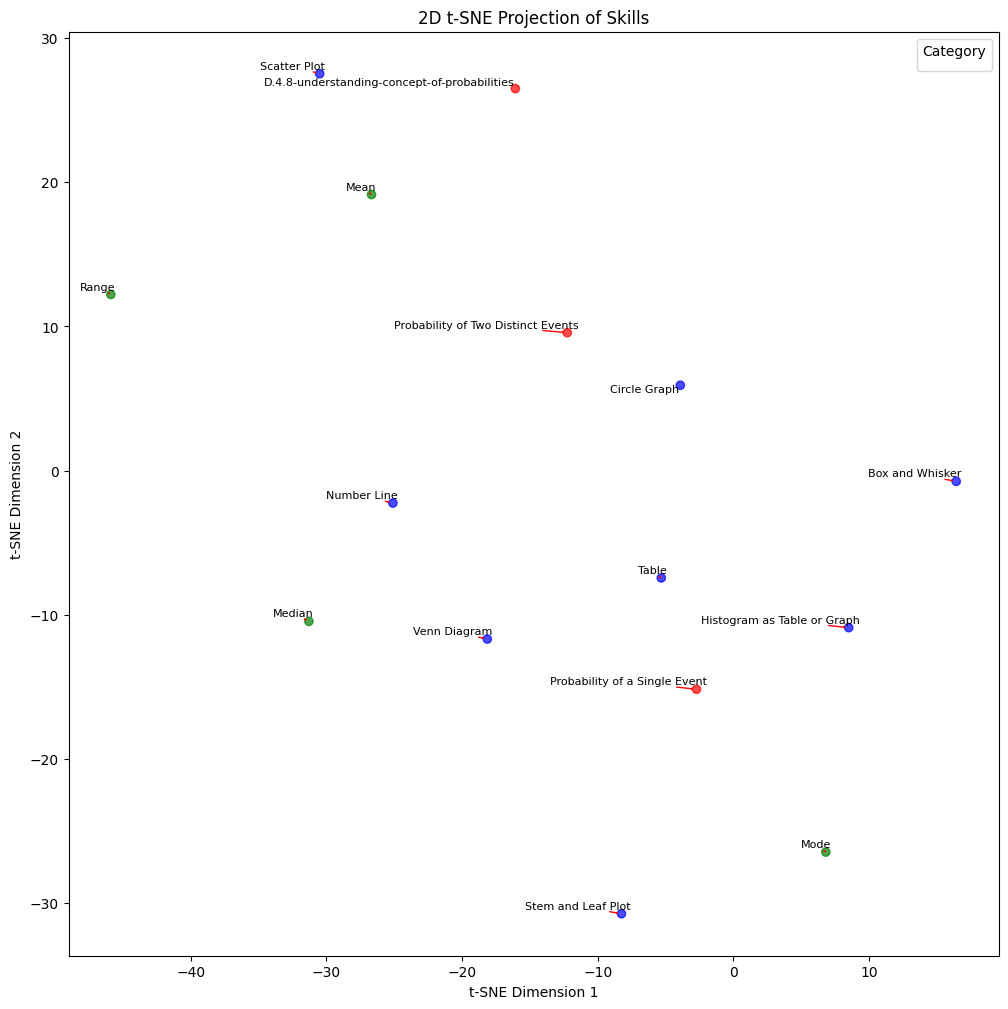

In [13]:
# Perform t-SNE to get 2D projections
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
df_embeddings[['tsne_1', 'tsne_2']] = tsne.fit_transform(df_embeddings.iloc[:, :7])

# Set up color mapping based on the category column
category_colors = {category: color for category, color in zip(df_embeddings['category'].unique(), ['b', 'g', 'r', 'orange', 'yellow', 'black', 'brown', 'purple', 'grey', 'pink', 'cyan'])}
df_embeddings['color'] = df_embeddings['category'].map(category_colors)

# Plotting
plt.figure(figsize=(12, 12))

# Scatter plot, color by category
plt.scatter(df_embeddings['tsne_1'], df_embeddings['tsne_2'], c=df_embeddings['color'], alpha=0.7)

# Add text labels
texts = []
for i, row in df_embeddings.iterrows():
    texts.append(plt.text(row['tsne_1'], row['tsne_2'], row['skill_name'], fontsize=8, ha='right', va='bottom'))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Add labels and title
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('2D t-SNE Projection of Skills')

# Add legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, title="Category")

# Show plot
plt.show()


# 4) Clustering

## 4.1) Hierarchical Clustering

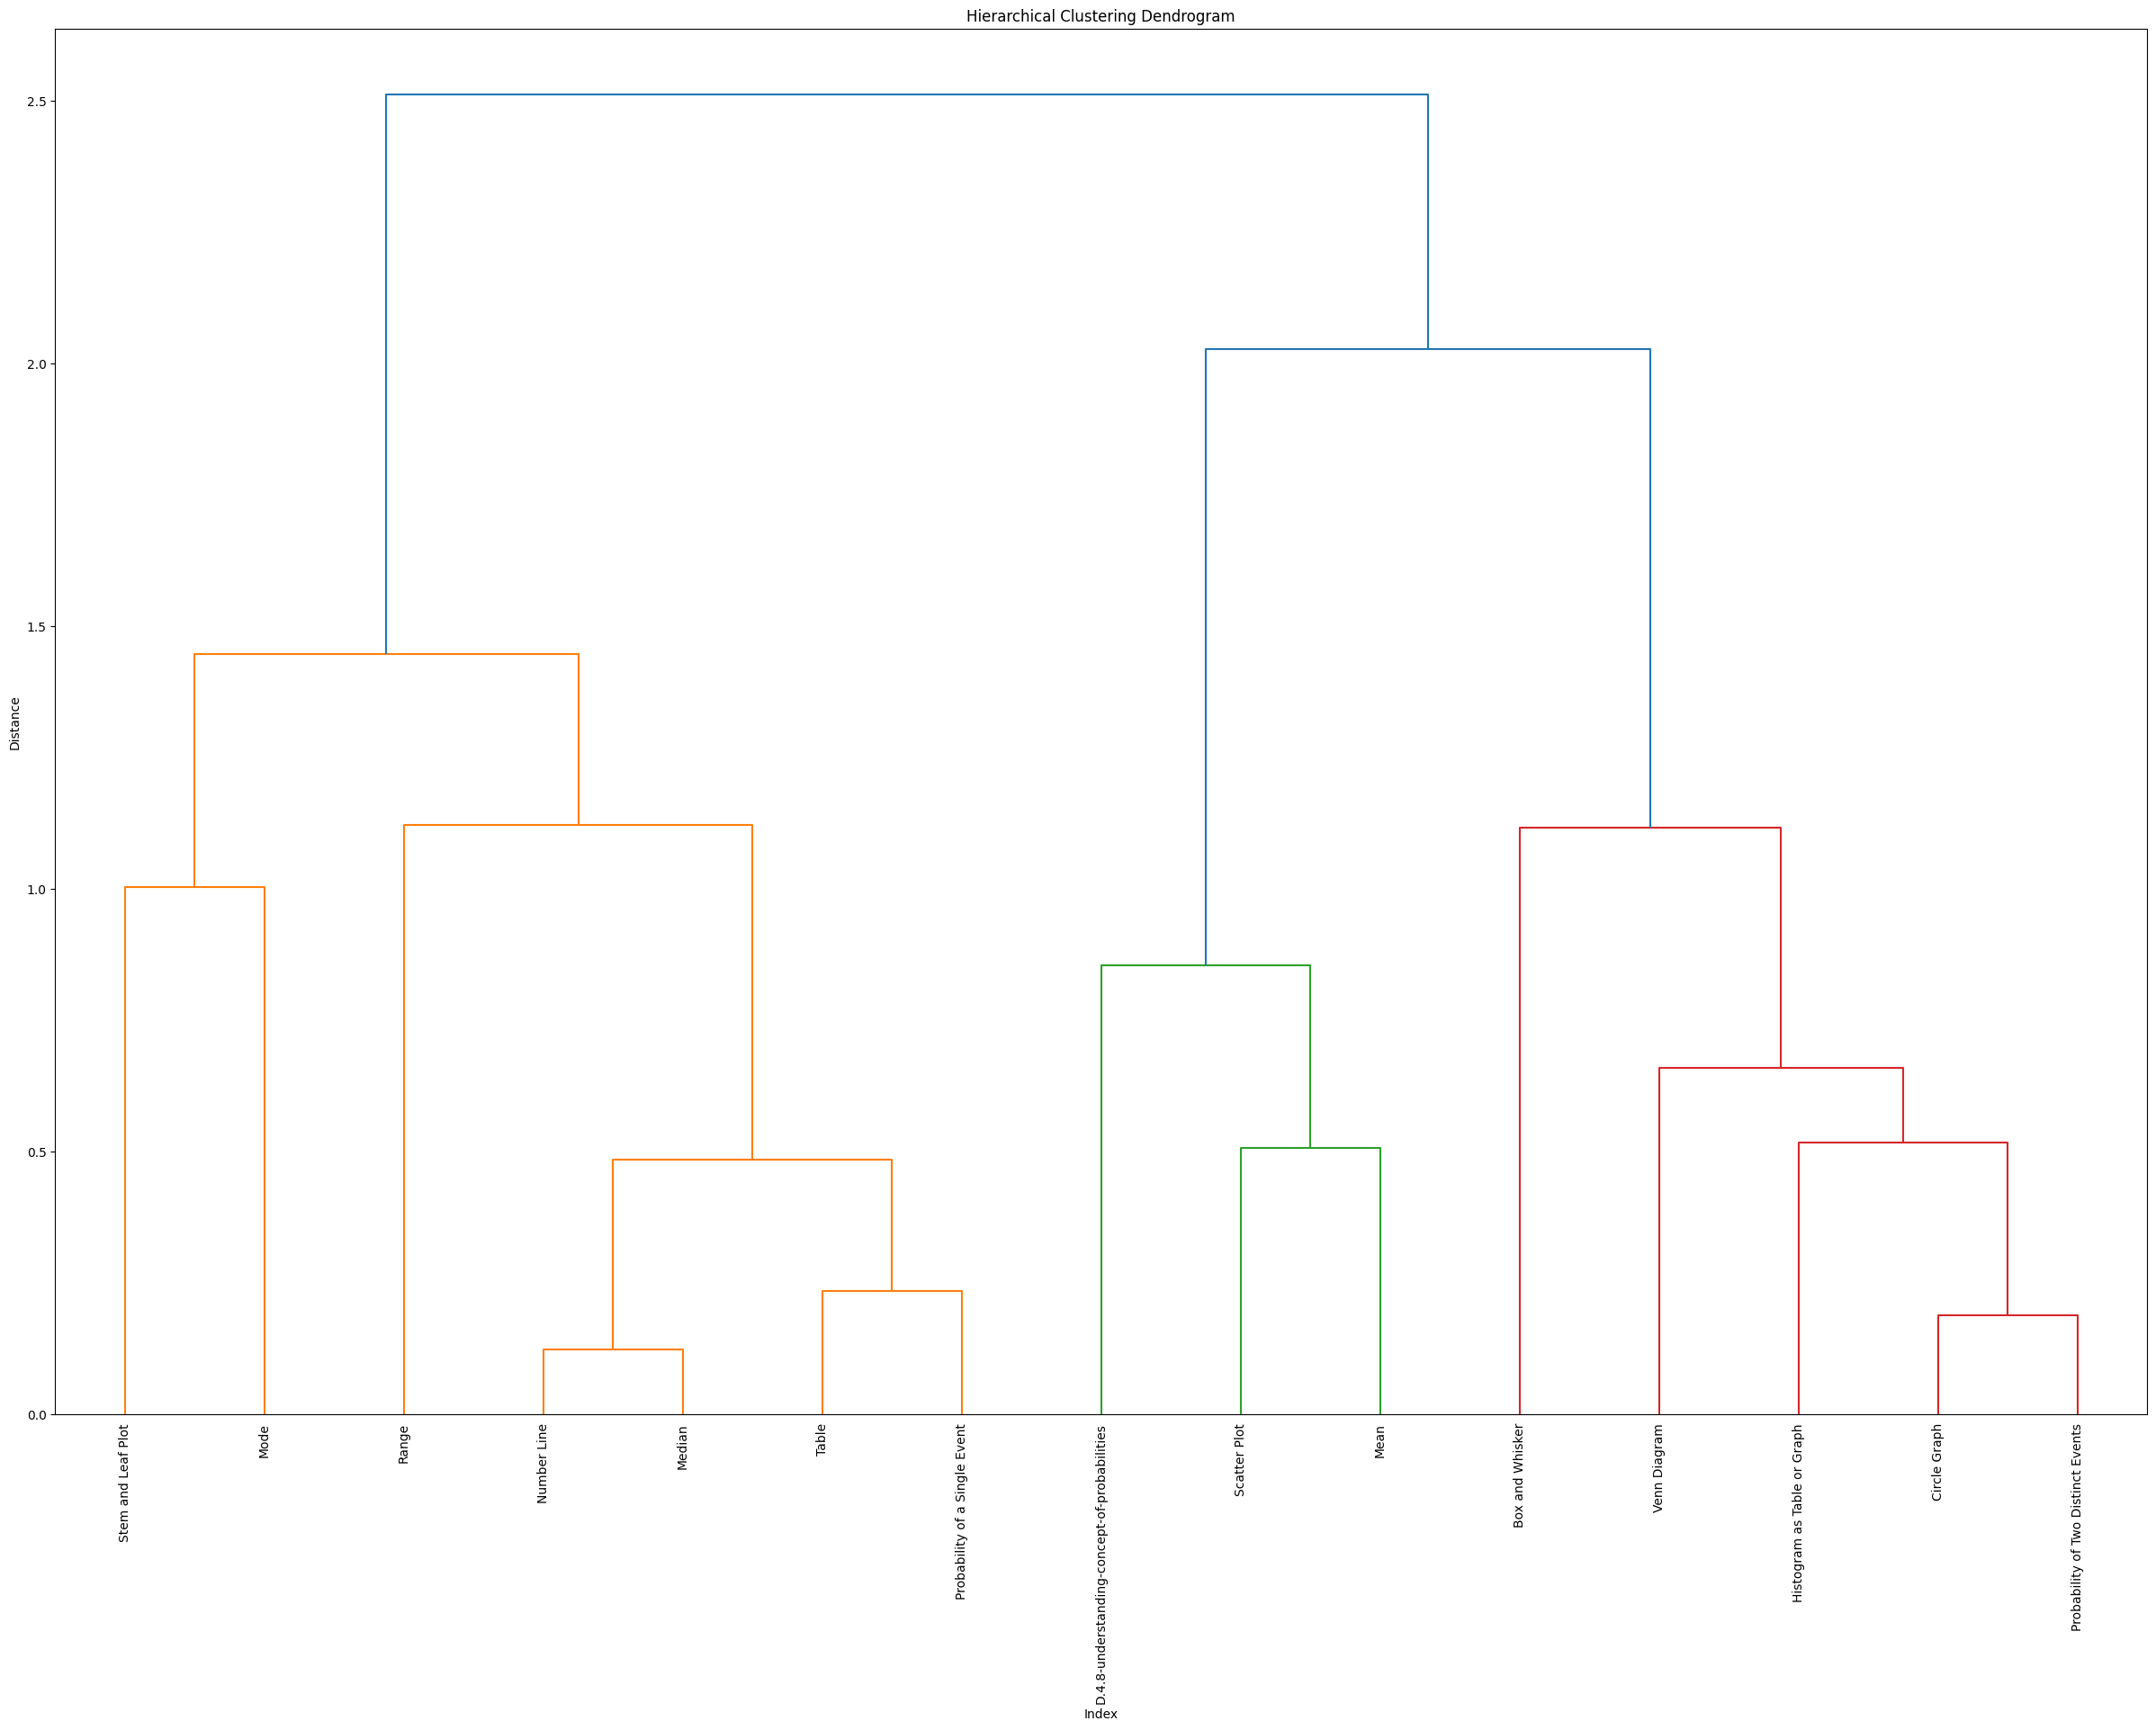

In [14]:
# Calculate the hierarchical matrix
linkage_matrix = sch.linkage(df_embeddings[['embedding_1', 'embedding_2', 'embedding_3']], method='ward')

plt.figure(figsize=(30, 20))
sch.dendrogram(linkage_matrix, labels=df_embeddings['skill_name'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()


## 4.2) K-Means Clustering

### 4.2.1) Elbow-method


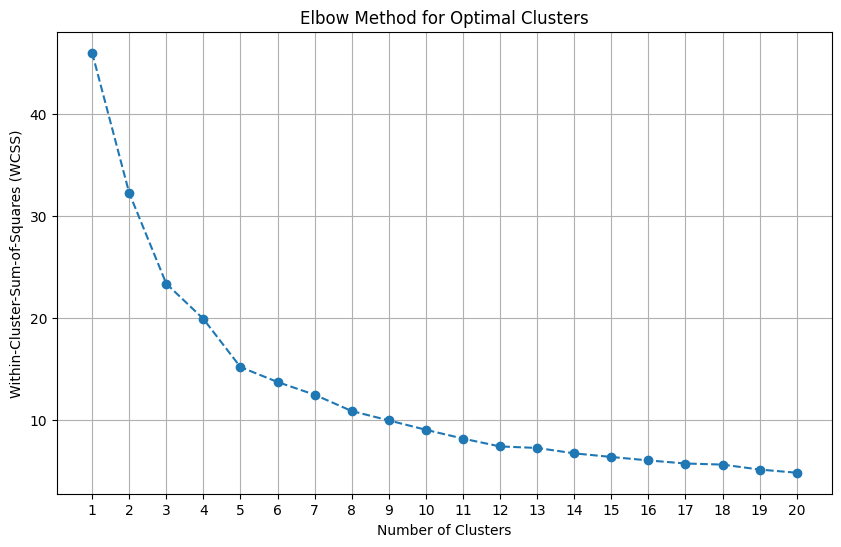

In [8]:
# Data preparation
data = df_embeddings.iloc[:, :7]

wcss_list = []
range_n_clusters = range(1, 21)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(data)
    wcss_list.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, wcss_list, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster-Sum-of-Squares (WCSS)')
plt.xticks(range_n_clusters)
plt.grid()
plt.show()


The number of clusters should be 5.

In [17]:
n_clusters = 3

# KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_embeddings['cluster'] = kmeans.fit_predict(data)

for cluster in range(n_clusters):
    print(f"Cluster {cluster+1}:")
    skills = df_embeddings[df_embeddings['cluster'] == cluster]['skill_name'].tolist()
    print(", ".join(skills))
    print("-" * 400)



Cluster 1:
Stem and Leaf Plot, Mode
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Cluster 2:
Number Line, Venn Diagram, Mean, Median
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Cluster 3:
Box and Whisker, Circle Graph, Histogram as Table or Graph, Scatter Plot, Table, Range, Probability 